
# Figure 1 — Ecological and taxonomic distribution of amino acid-degrading enzyme activities

This notebook generates the final 6-panel figure for the enzyme abundance analysis.

**Panels**

Top row:

- **A** Global enzyme prevalence
- **B** Enzyme prevalence by sampling site
- **C** Enzyme prevalence by halophily class
- **D** Enzyme prevalence by genus

Bottom row:

- **E** Halophily-enzyme prevalence matrix
- **F** Genus-enzyme prevalence matrix

The analysis intentionally uses only:

- `Site`
- `Halophily`
- `Genus`
- enzyme presence/absence columns

It does **not** use NaCl, pH, phylum, identity percentage, query coverage, or accession numbers.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# =============================================================================
# Paths
# =============================================================================

DATA_PATH = Path("../raw_data/atacama_enzyme_master_table.csv")

OUTDIR = Path("../figures_paper")
OUTDIR.mkdir(exist_ok=True)

# =============================================================================
# Load data
# =============================================================================

df = pd.read_csv(DATA_PATH)

enzyme_cols = ["ASNase", "ADI", "GLNase", "GO", "MGL", "SDH"]

# Keep only the columns used in this figure
df = df[["Isolate", "Site", "Halophily", "Genus"] + enzyme_cols].copy()

# Fixed order for interpretability
site_order = ["Valle de la Luna", "Salar de Tara"]
halophily_order = ["HA", "HM", "HE"]
genus_order = ["Calidifontibacillus", "Salibacterium", "Bacillus"]

# Remove empty categories if the input changes in the future
site_order = [x for x in site_order if x in df["Site"].unique()]
halophily_order = [x for x in halophily_order if x in df["Halophily"].unique()]
genus_order = [x for x in genus_order if x in df["Genus"].unique()]

# =============================================================================
# Derived summaries
# =============================================================================

global_counts = df[enzyme_cols].sum()
global_prev = df[enzyme_cols].mean() * 100

site_prev = df.groupby("Site")[enzyme_cols].mean().loc[site_order] * 100
halophily_prev = df.groupby("Halophily")[enzyme_cols].mean().loc[halophily_order] * 100
genus_prev = df.groupby("Genus")[enzyme_cols].mean().loc[genus_order] * 100

site_n = df["Site"].value_counts().to_dict()
halophily_n = df["Halophily"].value_counts().to_dict()
genus_n = df["Genus"].value_counts().to_dict()

display(df.head())
print("Global enzyme counts")
print(global_counts)
print("\nSite n")
print(site_n)
print("\nHalophily n")
print(halophily_n)
print("\nGenus n")
print(genus_n)


,Isolate,Site,Halophily,Genus,ASNase,ADI,GLNase,GO,MGL,SDH
0,VL 1,Valle de la Luna,HA,Bacillus,1,1,0,0,0,0
1,VL 2,Valle de la Luna,HM,Bacillus,1,1,1,1,0,1
2,VL 3,Valle de la Luna,HA,Calidifontibacillus,1,1,1,0,0,0
3,VL 4,Valle de la Luna,HA,Bacillus,1,1,1,0,0,0
4,VL 5,Valle de la Luna,HA,Bacillus,1,1,1,0,0,0


Global enzyme counts
ASNase    48
ADI       48
GLNase    24
GO        17
MGL        6
SDH        5
dtype: int64

Site n
{'Valle de la Luna': 37, 'Salar de Tara': 11}

Halophily n
{'HA': 22, 'HM': 15, 'HE': 11}

Genus n
{'Bacillus': 36, 'Salibacterium': 11, 'Calidifontibacillus': 1}


## Styling helpers

In [2]:

# =============================================================================
# Figure style
# =============================================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.labelsize": 9,
    "axes.titlesize": 9.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "figure.titlesize": 11,
    "axes.linewidth": 0.75,
    "xtick.major.width": 0.75,
    "ytick.major.width": 0.75,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Palette inspired by the current viability figure:
# dark teal / cyan / green, with softer companion colors for grouped bars.
enzyme_color = "#0EA5B9"

site_palette = {
    "Valle de la Luna": "#1F77B4",
    "Salar de Tara": "#9ECAE1"
}

halophily_palette = {
    "HA": "#1B9E77",
    "HM": "#66A61E",
    "HE": "#D95F02"
}

genus_palette = {
    "Bacillus": "#7570B3",
    "Salibacterium": "#C2A5CF",
    "Calidifontibacillus": "#E7298A"
}

# Heatmap colormap matching the teal-green family of the current paper figures.
heatmap_cmap = LinearSegmentedColormap.from_list(
    "enzyme_teal_green",
    ["#F7FCF5", "#C7EFCF", "#5ED6A3", "#00A6C8", "#006878"],
    N=256
)

def clean_axis(ax, grid_axis="y"):
    """Apply a clean, publication-like axis style."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")
    ax.tick_params(axis="both", colors="#222222", width=0.75, length=3)
    if grid_axis:
        ax.grid(True, axis=grid_axis, color="#E6E6E6", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

def add_panel_label(ax, label, x=-0.16, y=1.10):
    """Add panel label outside the axis."""
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="left"
    )

def annotate_bars(ax, bars, values, mode="percent", fontsize=7):
    """Annotate bars with percent or count labels."""
    for bar, value in zip(bars, values):
        height = bar.get_height()
        if mode == "percent":
            label = f"{value:.0f}%"
        else:
            label = f"{int(value)}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 2.0,
            label,
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color="#222222",
            rotation=0
        )

def grouped_barplot(ax, table, group_order, palette, ylabel="Positive isolates (%)"):
    """Grouped bar plot using only matplotlib."""
    x = np.arange(len(enzyme_cols))
    n_groups = len(group_order)
    total_width = 0.78
    bar_width = total_width / n_groups
    offsets = np.linspace(
        -total_width / 2 + bar_width / 2,
        total_width / 2 - bar_width / 2,
        n_groups
    )

    for i, group in enumerate(group_order):
        values = table.loc[group, enzyme_cols].values
        label = group
        bars = ax.bar(
            x + offsets[i],
            values,
            width=bar_width * 0.92,
            color=palette[group],
            edgecolor="white",
            linewidth=0.4,
            label=label,
            zorder=3
        )

    ax.set_xticks(x)
    ax.set_xticklabels(enzyme_cols, rotation=45, ha="right")
    ax.set_ylim(0, 108)
    ax.set_ylabel(ylabel)
    clean_axis(ax)
    return ax

def matrix_heatmap(ax, matrix, row_labels, col_labels, title=None):
    """Draw annotated heatmap with matplotlib only."""
    data = matrix.values

    im = ax.imshow(data, aspect="auto", cmap=heatmap_cmap, vmin=0, vmax=100)

    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=0)

    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)

    # Thin white gridlines
    ax.set_xticks(np.arange(-.5, len(col_labels), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(row_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.9)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            text_color = "white" if value >= 65 else "#111111"
            ax.text(
                j, i, f"{value:.0f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=8,
                fontweight="bold" if value in [0, 100] else "normal"
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlabel("Enzyme")

    return im


## Final 6-panel figure

Updated layout:

Top row: A | B | E (E spans 2 columns)

Bottom row: C | D | F (F spans 2 columns)


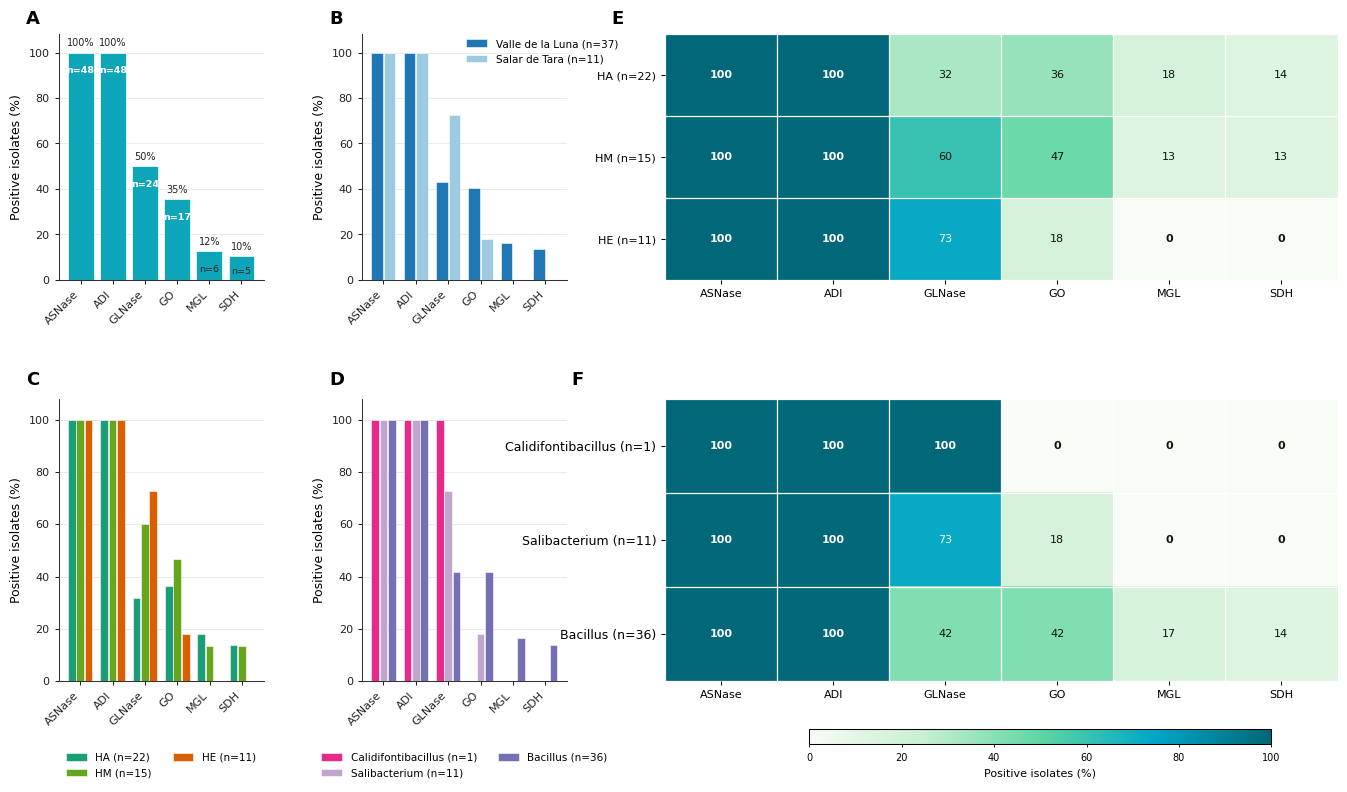

Saved PNG: ../figures_paper/figure1_ecological_enzyme_abundance_panel.jpg
Saved PDF: ../figures_paper/figure1_ecological_enzyme_abundance_panel.pdf
Saved SVG: ../figures_paper/figure1_ecological_enzyme_abundance_panel.svg


In [3]:

# =============================================================================
# Figure construction
# =============================================================================

fig = plt.figure(figsize=(16.5, 8.4), constrained_layout=False)

gs = GridSpec(
    nrows=2,
    ncols=4,
    figure=fig,
    width_ratios=[1,1,1.4,1.4],
    height_ratios=[1,1.15],
    hspace=0.45,
    wspace=0.40
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axE = fig.add_subplot(gs[0, 2:4])

axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])
axF = fig.add_subplot(gs[1, 2:4])

# =============================================================================
# A. Global prevalence
# =============================================================================

x = np.arange(len(enzyme_cols))
bars = axA.bar(
    x,
    global_prev.loc[enzyme_cols].values,
    color=enzyme_color,
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)
axA.set_xticks(x)
axA.set_xticklabels(enzyme_cols, rotation=45, ha="right")
axA.set_ylim(0, 108)
axA.set_ylabel("Positive isolates (%)")
clean_axis(axA)
annotate_bars(axA, bars, global_prev.loc[enzyme_cols].values, mode="percent")
add_panel_label(axA, "A")

# Add counts below the percentage labels as subtle text
for bar, count in zip(bars, global_counts.loc[enzyme_cols].values):
    axA.text(
        bar.get_x() + bar.get_width() / 2,
        max(bar.get_height() - 8, 4),
        f"n={int(count)}",
        ha="center",
        va="center",
        fontsize=6.8,
        color="white" if bar.get_height() > 35 else "#222222",
        fontweight="bold" if bar.get_height() > 35 else "normal"
    )

# =============================================================================
# B. Site prevalence
# =============================================================================

grouped_barplot(axB, site_prev, site_order, site_palette)
add_panel_label(axB, "B")
site_handles, site_labels = axB.get_legend_handles_labels()
site_labels = [f"{label} (n={site_n[label]})" for label in site_labels]
axB.legend(
    site_handles,
    site_labels,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.88, 1.02),
    ncol=1
)

# =============================================================================
# C. Halophily prevalence
# =============================================================================

grouped_barplot(axC, halophily_prev, halophily_order, halophily_palette)
add_panel_label(axC, "C")
halo_handles, halo_labels = axC.get_legend_handles_labels()
halo_labels = [f"{label} (n={halophily_n[label]})" for label in halo_labels]
axC.legend(
    halo_handles,
    halo_labels,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5,-0.22),
    ncol=2
)

# =============================================================================
# D. Genus prevalence
# =============================================================================

grouped_barplot(axD, genus_prev, genus_order, genus_palette)
add_panel_label(axD, "D")
genus_handles, genus_labels = axD.get_legend_handles_labels()
genus_labels = [f"{label} (n={genus_n[label]})" for label in genus_labels]
axD.legend(
    genus_handles,
    genus_labels,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5,-0.22),
    ncol=2
)

# =============================================================================
# E. Halophily enrichment heatmap
# =============================================================================

halo_heat = halophily_prev.loc[halophily_order, enzyme_cols]
imE = matrix_heatmap(
    axE,
    halo_heat,
    row_labels=[f"{x} (n={halophily_n[x]})" for x in halophily_order],
    col_labels=enzyme_cols,
    title="Halophily-enzyme prevalence matrix"
)
axE.set_ylabel("")
axE.set_xlabel("")
add_panel_label(axE, "E", x=-0.08, y=1.10)

# =============================================================================
# F. Genus enrichment heatmap
# =============================================================================

genus_heat = genus_prev.loc[genus_order, enzyme_cols]
imF = matrix_heatmap(
    axF,
    genus_heat,
    row_labels=[f"{x} (n={genus_n[x]})" for x in genus_order],
    col_labels=enzyme_cols,
    title="Genus-enzyme prevalence matrix"
)
axF.set_ylabel("")
axF.set_xlabel("")
axF.tick_params(axis="y", labelsize=9)
add_panel_label(axF, "F", x=-0.14, y=1.10)

# Shared colorbar for both heatmaps

norm = Normalize(vmin=0, vmax=100)
sm = ScalarMappable(norm=norm, cmap=heatmap_cmap)
sm.set_array([])

cbar_ax = fig.add_axes([0.58, 0.035, 0.28, 0.018])

cbar = fig.colorbar(
    sm,
    cax=cbar_ax,
    orientation="horizontal"
)

cbar.set_label("Positive isolates (%)", fontsize=8)

cbar.ax.tick_params(labelsize=7, width=0.6, length=2.5)

# Export
png_path = OUTDIR / "figure1_ecological_enzyme_abundance_panel.jpg"
pdf_path = OUTDIR / "figure1_ecological_enzyme_abundance_panel.pdf"
svg_path = OUTDIR / "figure1_ecological_enzyme_abundance_panel.svg"

fig.savefig(png_path, dpi=600, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")

plt.show()

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")
print(f"Saved SVG: {svg_path}")
